# IMT 573 - Lab 7 - Regression

### Instructions

Before beginning this assignment, please ensure you have access to a working instance of Jupyter Notebooks with Python 3.

1. First, replace the “YOUR NAME HERE” text in the next cell with your own full name. Any collaborators must also be listed in this cell.

2. Be sure to include well-documented (e.g. commented) code cells, figures, and clearly written text  explanations as necessary. Any figures should be clearly labeled and appropriately referenced within the text. Be sure that each visualization adds value to your written explanation; avoid redundancy – you do no need four different visualizations of the same pattern.

3. Collaboration on problem sets and labs is fun, useful, and encouraged. However, each student must turn in an individual write-up in their own words as well as code/work that is their own. Regardless of whether you work with others, what you turn in must be your own work; this includes code and interpretation of results. The names of all collaborators must be listed on each assignment. Do not copy-and-paste from other students’ responses or code - your code should never be on any other student's screen or machine.

4. All materials and resources that you use (with the exception of lecture slides) must be appropriately referenced within your assignment.

Name: Anika Mohan

Collaborators: 

Sources:

Perplexity Pro helped me with my understanding of the following concepts that I used to complete the assignment:
- residual plots
- OLS regression

In this module, we have focused on statistical modeling. In this lab, you'll explore the concept of regression model using the same baseball data as the previous lab. As a refresher, baseball is a bat-and-ball sport played in countries around the world including the United States, Canada, Cuba, the Dominican Republic, and Japan, to name a few. Baseball is a played between two teams who take turns batting and fielding. The objective of the game is to score "runs" by getting on "bases" with either "hits" or "walks". A run is scored when a player advances around the bases and returns to home plate. You can learn more [here](https://en.wikipedia.org/wiki/Baseball).

We will use the same dataset of baseball game statistics from 2010-2013 as the previous lab. You can learn more about the dataset at www.retrosheet.org/.

In [1]:
import pandas as pd
import statsmodels.api as sm
import seaborn as sns

### Problem 1: Set up data

What is the relationship between the number of at-bats a team gets and the number of runs they score over the course of an entire baseball season? This is the question we will explore in this lab. 

#### (a) Import data

To begin, load the data found in the `GL2010.TXT`, `GL2011.TXT`, `GL2012.TXT`, `GL2013.TXT` into a single dataframe. You can find column names for the data in the `cnames.txt` file. You should ultimately have 9,720 rows of data.

In [21]:
with open("cnames.txt") as f:
    col_names_wrong = [line.strip() for line in f.readlines()]
print(col_names_wrong[:7])
col_names_correct = pd.read_csv('cnames.txt')['Name'].tolist()
print(col_names_correct[:7])

['Name', 'Date', 'Numberofgame', 'Day', 'Visitor', 'VisitorLeague', 'VisitorGameNum']
['Date', 'Numberofgame', 'Day', 'Visitor', 'VisitorLeague', 'VisitorGameNum', 'Home']


In [12]:
with open("cnames.txt") as f:
    col_names = [line.strip() for line in f.readlines()]
print(col_names)
files = ["GL2010.TXT", "GL2011.TXT", "GL2012.TXT", "GL2013.TXT"]

dfs = []
for file in files:
    df_file = pd.read_csv(file, names=col_names, header=None, delimiter=',')
    dfs.append(df_file)

df = pd.concat(dfs, ignore_index=True)

print(df.shape)
df.head()

['Name', 'Date', 'Numberofgame', 'Day', 'Visitor', 'VisitorLeague', 'VisitorGameNum', 'Home', 'HomeLeague', 'HomeGameNum', 'VisitorScore', 'HomeScore', 'Outs', 'DayorNight', 'Completion', 'Forfeit', 'Protest', 'ParkID', 'Attendance', 'DurationMinutes', 'VisitingLineScores', 'HomeLineScores', 'Vat-bats', 'Vhits', 'Vdoubles', 'Vtriples', 'Vhomeruns', 'VRBI', 'Vsacrificehits', 'Vsacrificeflies', 'Vhit-by-pitch', 'Vwalks', 'Vintentionalwalks', 'Vstrikeouts', 'Vstolenbases', 'Vcaughtstealing', 'Vgroundedintodoubleplays', 'Vawardedfirstoncatcherinterference', 'Vleftonbase', 'Vpitchersused', 'Vindividualearnedruns', 'Vteam arnedruns', 'Vwildpitches', 'Vbalks', 'Vputouts', 'Vassists', 'Verrors', 'Vpassed balls', 'Vdouble plays', 'Vtriple plays', 'Hat-bats', 'Hhits', 'Hdoubles', 'Htriples', 'Hhomeruns', 'HRBI', 'Hsacrificehits', 'Hsacrificeflies', 'Hhit-by-pitch', 'Hwalks', 'Hintentionalwalks', 'Hstrikeouts', 'Hstolenbases', 'Hcaughtstealing', 'Hgroundedintodoubleplays', 'Hawardedfirstoncatcher

,Name,Date,Numberofgame,Day,Visitor,VisitorLeague,VisitorGameNum,Home,HomeLeague,HomeGameNum,...,152,153,154,155,156,157,158,159,160,161
0,20100404,0,Sun,NYA,AL,1,BOS,AL,1,7,...,9,camem001,Mike Cameron,8,scutm001,Marco Scutaro,6,NaN,Y,NaN
1,20100405,0,Mon,MIN,AL,1,ANA,AL,1,3,...,4,woodb003,Brandon Wood,5,mathj001,Jeff Mathis,2,NaN,Y,NaN
2,20100405,0,Mon,CLE,AL,1,CHA,AL,1,0,...,2,teahm001,Mark Teahen,5,ramia003,Alexei Ramirez,6,NaN,Y,NaN
3,20100405,0,Mon,DET,AL,1,KCA,AL,1,8,...,6,kendj001,Jason Kendall,2,getzc001,Chris Getz,4,NaN,Y,NaN
4,20100405,0,Mon,SEA,AL,1,OAK,AL,1,5,...,4,buckt001,Travis Buck,7,pennc001,Cliff Pennington,6,NaN,Y,NaN


#### (b) Pull years

For this exercise, we need data for each team (30 in total) for each season in the dataset (4 seasons). Each season is designated by the year in which the games were played, which can be pulled from the `Date` variable. Start by creating a `Year` variable.

In [3]:
df["Year"] = df['Name'].astype(str).str[:4]

In [4]:
print(df["Year"].unique())

['2010' '2011' '2012' '2013']


#### (c) Aggregate data

Next, aggregate the scores and at-bats for each team across each season. Note that we do not make a distinction between home team and away team. You should have 120 records after aggregating (one for each team for each season).

In [17]:
df[['Home','Visitor', 'Day']]

,Home,Visitor,Day
0,AL,AL,NYA
1,AL,AL,MIN
2,AL,AL,CLE
3,AL,AL,DET
4,AL,AL,SEA
...,...,...,...
9715,NL,AL,DET
9716,NL,NL,MIL
9717,NL,NL,SDN
9718,NL,NL,CHN


In [11]:
home = df[['Year', 'Day', 'HomeScore', 'Hat-bats']].copy()
home.columns = ['Year', 'Team', 'Runs', 'AtBats']

visitor = df[['Year', 'Day', 'VisitorScore', 'Vat-bats']].copy()
visitor.columns = ['Year', 'Team', 'Runs', 'AtBats']

combine = pd.concat([home, visitor], ignore_index=True)

agg_scores = combine.groupby(['Year', 'Team'], as_index=False).agg({'Runs': 'sum', 'AtBats':'sum'})
print(agg_scores.shape)
agg_scores.head()

(120, 4)


,Year,Team,Runs,AtBats
0,2010,ANA,4677,1431
1,2010,ARI,4735,1400
2,2010,ATL,4646,1370
3,2010,BAL,4653,1420
4,2010,BOS,4730,1434


### Problem 2: Regression

#### (a) Plot relationship

Plot the relationship between runs and at-bats. Does the relationship look linear? Describe the
relationship between these two variables.

<Axes: title={'center': 'Runs vs At-Bats for each Team-Season'}, xlabel='AtBats'>

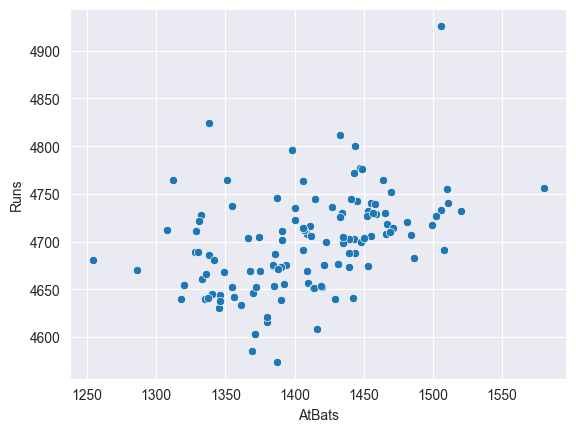

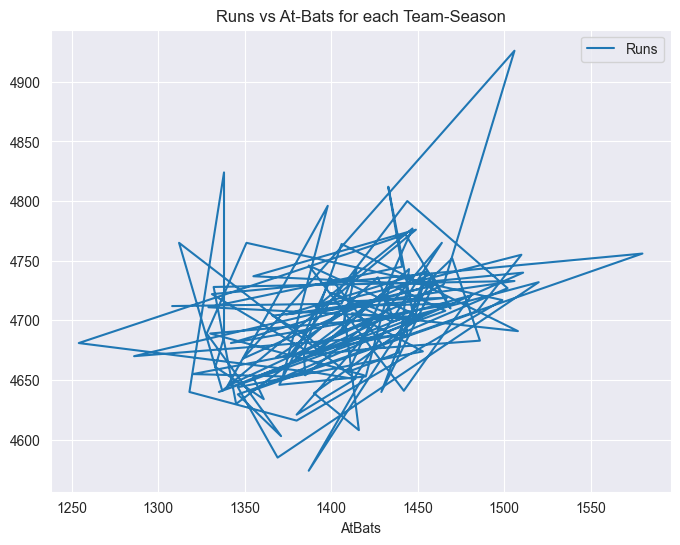

In [6]:
sns.scatterplot(x='AtBats', y='Runs', data=agg_scores)
agg_scores.plot(x='AtBats', y='Runs', figsize=(8,6), title='Runs vs At-Bats for each Team-Season')

----> The scatterplot shows a positive relationship between total At-Bats and total runs scored for each team-season. Most of the teams wtih At-bats seemingly scoring more runs. The data points roughly show a linear trend which tells us that At-Bat is a good predicitor of runs across all teams and seasons.

#### (b) Assessing relationship

If you knew a team’s at bats, would you be comfortable using a linear model to predict the number of
runs? Why or why not? Quantify the strength of the relationship with the correlation coefficient. Discuss what you find.

In [7]:
correlation = agg_scores['AtBats'].corr(agg_scores['Runs'])
print(correlation)

0.4103177385065515


The calculated correlation coefficient between at-bats and runs is 0.41. This moderate positive value indicates that more At-Bats tend to score more runs. Based on this, I would be comfortable using a linear model to predict the number of runs as the linear model would provide a reasonable prediction. 


#### (c) Modeling

Use the `statsmodels` package to fit a simple linear model for runs as a function of at-bats. Ensure a constant (intercept) has been added to the regression. Write down the formula for the model, filling in estimated coefficient values.

In [8]:
import statsmodels.api as sm

x = agg_scores['AtBats']
y = agg_scores['Runs']
X = sm.add_constant(x)

model = sm.OLS(y, x).fit()
print(model.summary())


                                 OLS Regression Results                                
Dep. Variable:                   Runs   R-squared (uncentered):                   0.999
Model:                            OLS   Adj. R-squared (uncentered):              0.999
Method:                 Least Squares   F-statistic:                          8.664e+04
Date:                Sat, 15 Nov 2025   Prob (F-statistic):                   3.38e-172
Time:                        22:51:17   Log-Likelihood:                         -789.38
No. Observations:                 120   AIC:                                      1581.
Df Residuals:                     119   BIC:                                      1584.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

Regression Formula:

Runs = a + b x AtBats
** a = intercept
** b = slope

#### (d) Interpretation

Describe in words the interpretation of $\beta$<sub>1</sub>.

-----> The coefficient for Atbat (3.33) means that on average for each additional unit of At-Bat a team has in a season, the total number of runs scored increases by about 3.33 runs. The coefficient (B1) quantifies the exp. change in runs per additional At-Bat across all team-seasons.


### Problem 3: Plotting

#### (a) Plot regression line

Make a plot of at-bats vs runs but include the fitted regression line. How well does the fitted line fit the data?

<Axes: xlabel='AtBats', ylabel='Runs'>

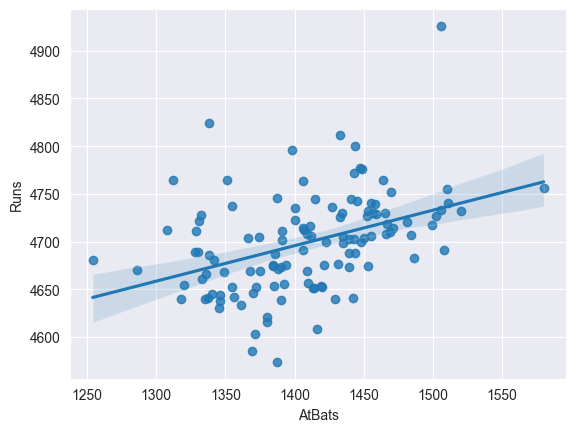

In [9]:
sns.regplot(x='AtBats', y='Runs', data=agg_scores)

The scatter plot with the regression line and shaded confidence interval shows a positive association between at-bats and runs for MLB teams in each season. However, while the fitted regression line follows the overall trend, there is much scatter in the data points straying away from the line which makes the line not as fitted to the data. 

#### (b) Plot residuals

Make a plot of the residuals versus at bats. Is there any apparent pattern in the residuals plot?

<Axes: xlabel='AtBats', ylabel='Runs'>

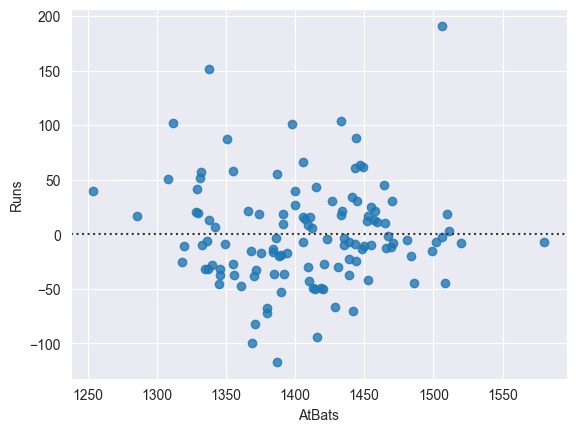

In [10]:
sns.residplot(data=agg_scores, x='AtBats', y='Runs', lowess=False)

- randomly scattered around zero with no clear pattern
- there is no visible shape and the spread of the residuals is fairly consistent
- does not show any strong pattern- indicating the linear model is appropriate
